In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = SparkSession.builder.master("local[10]").getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

df = spark.read.parquet("/home/h487/data/parquet/run1078_srppac_koji.parquet")
#df.show(5)
#df=df.filter("charge1_x > 0 AND charge1_y > 0 AND ABS(id0_x - id1_x) = 1 AND ABS(id0_y - id1_y) = 1 AND ABS(id0_x - id2_x) = 1 AND ABS(id0_y - id2_y) = 1")
df.show(20)
print(df.filter("charge1_x > 0 AND charge1_y > 0 AND ABS(id0_x - id1_x) = 1 AND ABS(id0_y - id1_y) = 1 AND ABS(id0_x - id2_x) = 1 AND ABS(id0_y - id2_y) = 1").count())

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/01/28 13:10:22 WARN Utils: Your hostname, gpuana02, resolves to a loopback address: 127.0.1.1; using 133.11.152.134 instead (on interface enp4s0)
26/01/28 13:10:22 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
26/01/28 13:10:22 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
{"ts": "2026-01-28 13:10:25.986", "level": "ERROR", "logger": "SQLQueryContextLogger", "msg": "[UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `charge1_x` cannot be resolved. Did you mean one of the following? [`sr_id0_x`, `sr_ins_x`, `sr_pos_x`, `runname`, `sr_id0_y`]. SQLSTATE: 42703",

+---------+--------+-------------------+--------------------+--------+-------------------+--------------------+-------+
|hbfNumber|sr_id0_x|           sr_pos_x|            sr_ins_x|sr_id0_y|           sr_pos_y|            sr_ins_y|runname|
+---------+--------+-------------------+--------------------+--------+-------------------+--------------------+-------+
|  1296782|      12|-11.460722279548644|  -1.260722279548645|       9|               NULL|                NULL|run1078|
|  1335842|      15|               NULL|                NULL|      21| 11.312619156837464|  0.9926191568374634|run1078|
|  1360763|      11|-14.028852510452271|  1.2711474895477295|      26|   24.6328332901001| -1.1671667098999023|run1078|
|  1378625|      16|               NULL|                NULL|      29| 32.178082785606385|  1.2180827856063843|run1078|
|  1347590|      19|               NULL|                NULL|      14| -6.445115242004395| -1.2851152420043945|run1078|
|  1348360|      15| -4.918596273660659|

AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `charge1_x` cannot be resolved. Did you mean one of the following? [`sr_id0_x`, `sr_ins_x`, `sr_pos_x`, `runname`, `sr_id0_y`]. SQLSTATE: 42703; line 1 pos 0;
'Filter (((('charge1_x > 0) AND ('charge1_y > 0)) AND ('ABS(('id0_x - 'id1_x)) = 1)) AND ((('ABS(('id0_y - 'id1_y)) = 1) AND ('ABS(('id0_x - 'id2_x)) = 1)) AND ('ABS(('id0_y - 'id2_y)) = 1)))
+- Relation [hbfNumber#0,sr_id0_x#1,sr_pos_x#2,sr_ins_x#3,sr_id0_y#4,sr_pos_y#5,sr_ins_y#6,runname#7] parquet


Statistics:
[[0.0000e+00 4.6200e+02 4.0000e+00]
 [0.0000e+00 4.4049e+04 5.4500e+02]
 [0.0000e+00 0.0000e+00 0.0000e+00]]
Statistics:
[[0.0000e+00 3.3500e+02 4.0000e+00]
 [0.0000e+00 4.3995e+04 6.5300e+02]
 [0.0000e+00 0.0000e+00 0.0000e+00]]


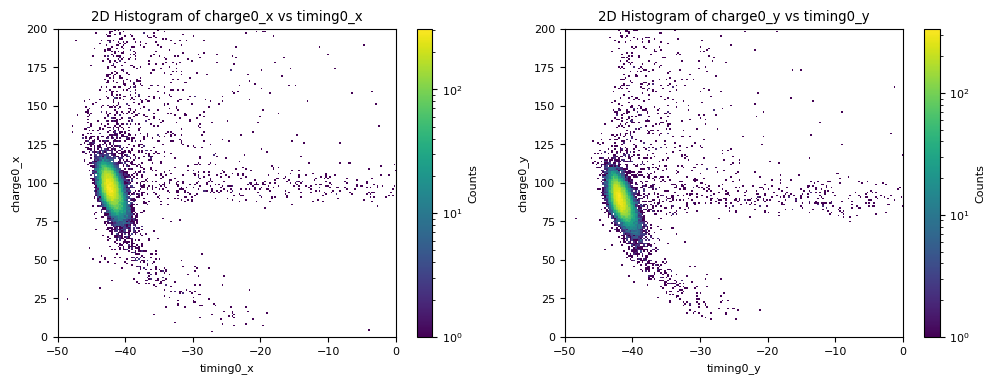

In [39]:
from hist.sparkHist2d import Hist2DArrays
from hist.sparkHist2d import Hist2D
from hist.sparkHist1d import Hist1D
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm

plt.figure(0, figsize=(12,4))
plt.rcParams["font.size"] = 8
plt.subplot2grid((1,2),(0,0))
h = Hist2D(df, ["timing0_x","charge0_x"], [200,200], [[-50, 0], [0, 200]], norm=LogNorm(), interpolation='none')
plt.subplot2grid((1,2),(0,1))
h = Hist2D(df, ["timing0_y","charge0_y"], [200,200], [[-50, 0], [0, 200]], norm=LogNorm(), interpolation='none')
plt.show()  

Total entries: 45060, Underflow: 0, Inside: 45016, Overflow: 44
Total entries: 44987, Underflow: 0, Inside: 44957, Overflow: 30


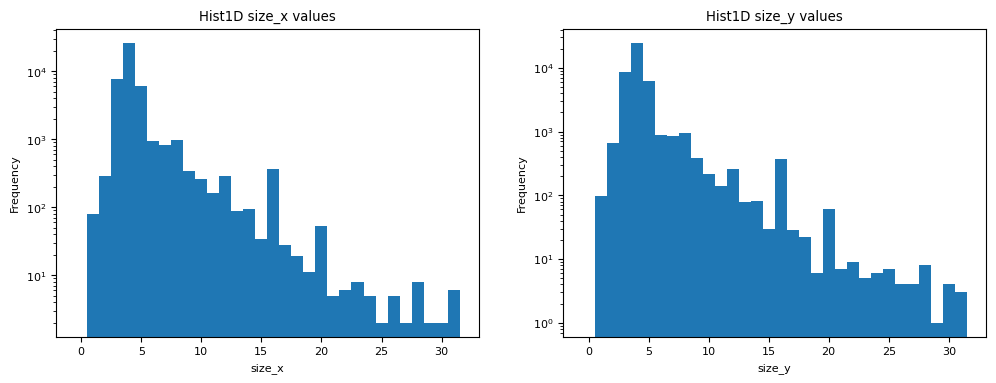

In [40]:
plt.figure(0, figsize=(12,4))
plt.rcParams["font.size"] = 8
plt.subplot2grid((1,2),(0,0))
h = Hist1D(df, "size_x", 33, [-0.5, 31.5])
plt.yscale('log')
plt.subplot2grid((1,2),(0,1))
h = Hist1D(df, "size_y", 33, [-0.5, 31.5])
plt.yscale('log')
plt.show()

Statistics:
[[0.0000e+00 1.0000e+00 0.0000e+00]
 [0.0000e+00 4.0483e+04 2.3000e+01]
 [0.0000e+00 0.0000e+00 0.0000e+00]]
Statistics:
[[0.0000e+00 0.0000e+00 0.0000e+00]
 [0.0000e+00 4.0501e+04 3.6000e+01]
 [0.0000e+00 0.0000e+00 0.0000e+00]]


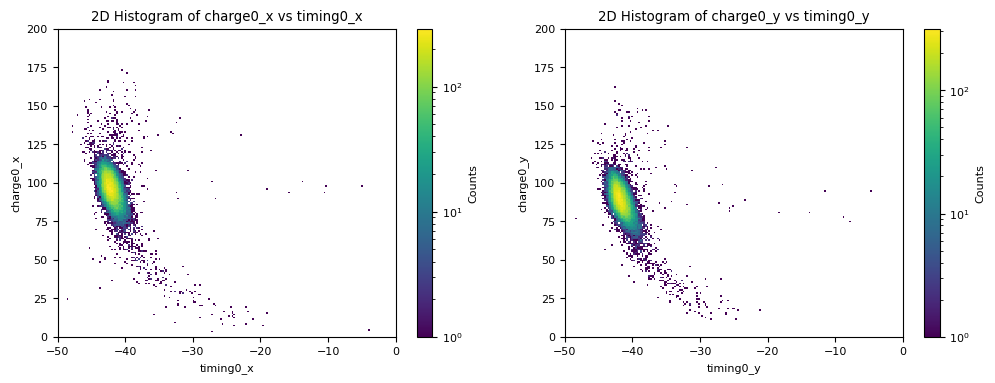

In [42]:
plt.figure(0, figsize=(12,4))
plt.rcParams["font.size"] = 8
plt.subplot2grid((1,2),(0,0))
h = Hist2D(df.filter("size_x<6"), ["timing0_x","charge0_x"], [200,200], [[-50, 0], [0, 200]], norm=LogNorm(), interpolation='none')
plt.subplot2grid((1,2),(0,1))
h = Hist2D(df.filter("size_y<6"), ["timing0_y","charge0_y"], [200,200], [[-50, 0], [0, 200]], norm=LogNorm(), interpolation='none')
plt.show() 

Statistics:
[[0.0000e+00 2.0000e+00 0.0000e+00]
 [0.0000e+00 3.9769e+04 0.0000e+00]
 [0.0000e+00 0.0000e+00 0.0000e+00]]
Statistics:
[[    0.     0.     0.]
 [    0. 39721.     0.]
 [    0.     0.     0.]]
Statistics:
[[0.0000e+00 0.0000e+00 0.0000e+00]
 [0.0000e+00 3.9467e+04 0.0000e+00]
 [0.0000e+00 2.0000e+00 0.0000e+00]]
Statistics:
[[    0.     0.     0.]
 [    0. 39771.     0.]
 [    0.     0.     0.]]
Statistics:
[[    0.     0.     0.]
 [    0. 39692.     0.]
 [    0.     0.     0.]]
Statistics:
[[0.0000e+00 0.0000e+00 0.0000e+00]
 [0.0000e+00 3.9044e+04 0.0000e+00]
 [0.0000e+00 2.0000e+00 0.0000e+00]]


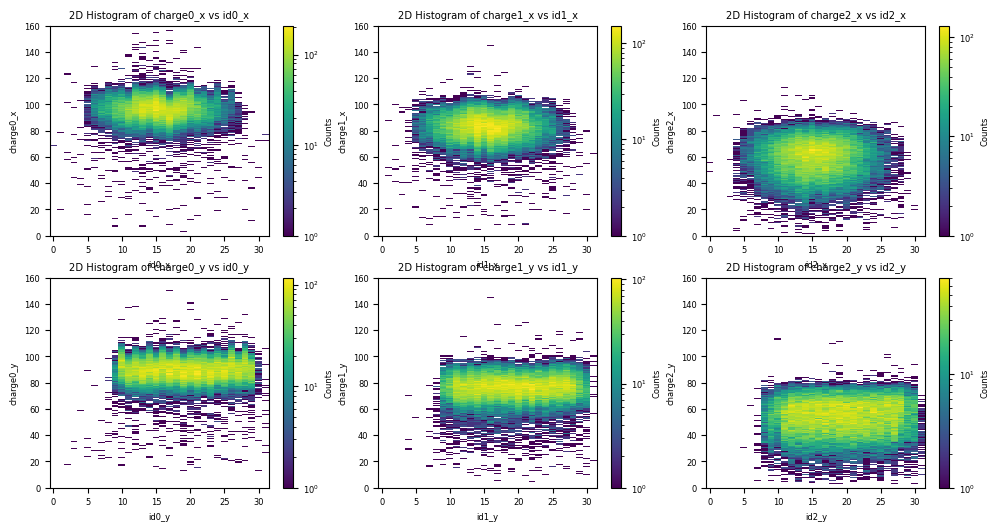

In [43]:
df_f = df.filter("size_x<6").filter("size_y<6")
plt.figure(0, figsize=(12,6))
plt.rcParams["font.size"] = 6
plt.subplot2grid((2,3),(0,0))
h = Hist2D(df_f, ["id0_x","charge0_x"], [33,200], [[-0.5, 31.5], [0, 160]], norm=LogNorm(), interpolation='none')
plt.subplot2grid((2,3),(0,1))
h = Hist2D(df_f, ["id1_x","charge1_x"], [33,200], [[-0.5, 31.5], [0, 160]], norm=LogNorm(), interpolation='none')
plt.subplot2grid((2,3),(0,2))
h = Hist2D(df_f, ["id2_x","charge2_x"], [33,200], [[-0.5, 31.5], [0, 160]], norm=LogNorm(), interpolation='none')
plt.subplot2grid((2,3),(1,0))
h = Hist2D(df_f, ["id0_y","charge0_y"], [33,200], [[-0.5, 31.5], [0, 160]], norm=LogNorm(), interpolation='none')
plt.subplot2grid((2,3),(1,1))
h = Hist2D(df_f, ["id1_y","charge1_y"], [33,200], [[-0.5, 31.5], [0, 160]], norm=LogNorm(), interpolation='none')
plt.subplot2grid((2,3),(1,2))
h = Hist2D(df_f, ["id2_y","charge2_y"], [33,200], [[-0.5, 31.5], [0, 160]], norm=LogNorm(), interpolation='none')
plt.show() 

Statistics:
[[    0.     0.     0.]
 [    0. 39771.     0.]
 [    0.     0.     0.]]


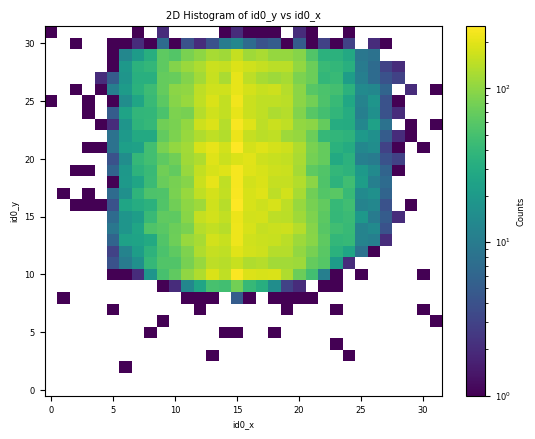

Statistics:
[[    0.     0.     0.]
 [    0. 39668.     0.]
 [    0.     0.     0.]]


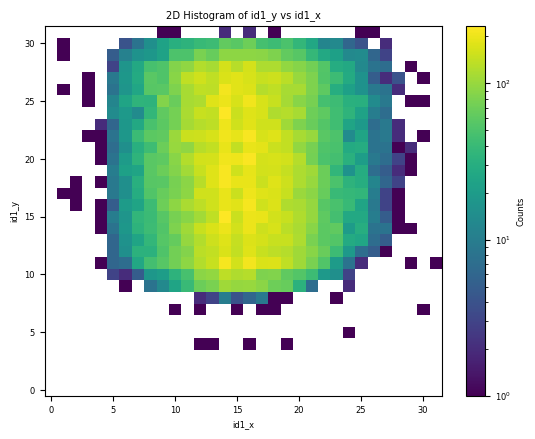

In [44]:
h = Hist2D(df_f, ["id0_x","id0_y"], [33,33], [[-0.5, 31.5], [-0.5,31.5]], norm=LogNorm(), interpolation='none')
plt.show()
h = Hist2D(df_f, ["id1_x","id1_y"], [33,33], [[-0.5, 31.5], [-0.5,31.5]], norm=LogNorm(), interpolation='none')

Statistics:
[[     0.      0.      0.]
 [     0. 126633.      0.]
 [     0.      0.      0.]]


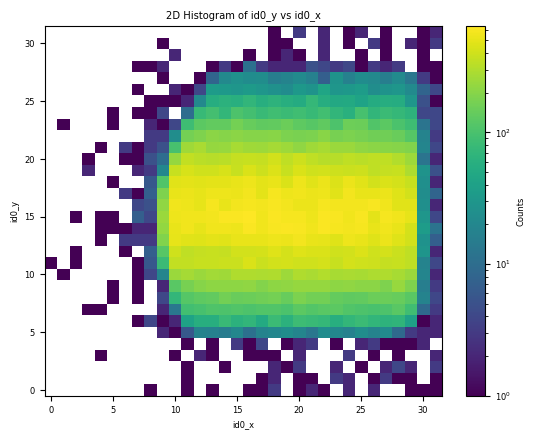

Statistics:
[[     0.      0.      0.]
 [     0. 126397.      0.]
 [     0.      0.      0.]]


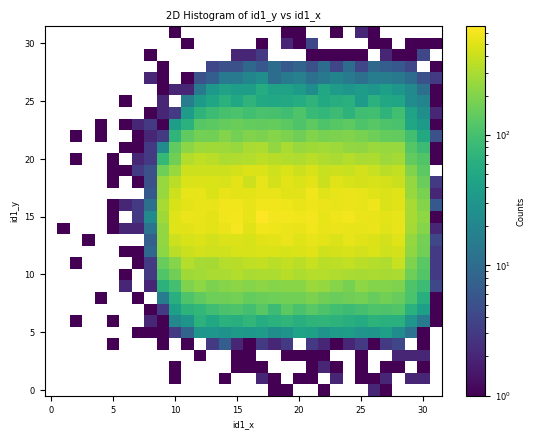

In [24]:
h = Hist2D(df_f, ["id0_x","id0_y"], [33,33], [[-0.5, 31.5], [-0.5,31.5]], norm=LogNorm(), interpolation='none')
plt.show()
h = Hist2D(df_f, ["id1_x","id1_y"], [33,33], [[-0.5, 31.5], [-0.5,31.5]], norm=LogNorm(), interpolation='none')